# Project: Sentiment Analysis on Amazon Reviews

# 1.1. Problem Definition
**Context:** In a high-volume e-commerce environment, manually reading every customer review is impossible. For global platforms, understanding customer satisfaction at scale is crucial for operational excellence and dispute prevention.

## 1.2. Objective
The goal of this project is to develop a Machine Learning model to automatically classify customer reviews based on **Sentiment Polarity** (Positive vs. Negative). This system enables the business to:
* **Automate feedback loops**: Flag unsatisfied customers in real-time.
* **Risk Mitigation**: Identify potential service failures before they escalate into chargebacks or formal disputes.
* **Prioritize Intervention**: Direct customer support resources toward high-impact negative feedback.

## 1.3. Expected Benefits
* **Scalability:** Replacing manual sentiment classification with a robust automated pipeline.
* **Proactivity:** Faster response times to negative trends, which is vital for maintaining trust in digital ecosystems.
* **Data-Driven Decisions:** Utilizing sentiment as a key performance indicator (KPI) for product and service quality.

## 2. Library Imports

**Description**: This section handles the environment setup. I import essential libraries such as Pandas for data manipulation, Matplotlib/Seaborn for data visualization, and Scikit-learn for the Machine Learning pipeline. This ensures all the necessary tools are available for data processing and model training

In [1]:
!pip install -q -U Watermark

In [2]:
# --- Step 1: Importing Essential Libraries ---

# General Purpose & System
import os
import re
import unicodedata
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

# Data Visualization & NLP Exploration
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from collections import Counter

# Scikit-learn Tools for Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# --- Step 2: Global Configurations & Version Control ---

# Setting visualization style
sns.set_style('whitegrid')
%matplotlib inline

# Version control and authorship
%reload_ext watermark
%watermark -a "Marco Antonio Moreira Pinto"

print(f"{'-'*18}\nVersions used:")
%watermark --iversions

Author: Marco Antonio Moreira Pinto

------------------
Versions used:
joblib    : 1.4.2
json      : 2.0.9
matplotlib: 3.10.0
numpy     : 2.1.3
pandas    : 2.2.3
re        : 2.2.1
seaborn   : 0.13.2
sklearn   : 1.6.1
wordcloud : 1.9.6



# 3. Data Loading & Initial Inspection

**Description**: In this phase, I load the raw dataset into the environment. Since the original file is in JSON format, I process it using Pandas and perform an initial inspection to understand the data structure, column types, and identify any missing values. This step is crucial for defining our "Target" (the rating) and our "Feature" (the review text).

In [4]:
# --- Step 1: Downloading the Dataset ---

import kagglehub

# Download latest version from Kaggle
path = kagglehub.dataset_download("abdallahwagih/amazon-reviews")
print("Path to dataset files:", path)

Path to dataset files: /Users/marcomoreira/.cache/kagglehub/datasets/abdallahwagih/amazon-reviews/versions/1


In [5]:
# --- Step 2: Loading the Specific JSON File ---

# Path provided by kagglehub
path = "/Users/marcomoreira/.cache/kagglehub/datasets/abdallahwagih/amazon-reviews/versions/1"

# The file name identified for this specific analysis
file_name = 'Cell_Phones_and_Accessories_5.json'
full_path = os.path.join(path, file_name)

# Reading the file based on its extension
# Using lines=True as each line is a separate JSON record
df = pd.read_csv(full_path, lines=True) if full_path.endswith('.csv') else pd.read_json(full_path, lines=True)

# Displaying the first 5 rows to confirm the data structure
df.head()

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,A30TL5EWN6DFXT,120401325X,christina,"[0, 0]",They look good and stick good! I just don't li...,4,Looks Good,1400630400,"05 21, 2014"
1,ASY55RVNIL0UD,120401325X,emily l.,"[0, 0]",These stickers work like the review says they ...,5,Really great product.,1389657600,"01 14, 2014"
2,A2TMXE2AFO7ONB,120401325X,Erica,"[0, 0]",These are awesome and make my phone look so st...,5,LOVE LOVE LOVE,1403740800,"06 26, 2014"
3,AWJ0WZQYMYFQ4,120401325X,JM,"[4, 4]",Item arrived in great time and was in perfect ...,4,Cute!,1382313600,"10 21, 2013"
4,ATX7CZYFXI1KW,120401325X,patrice m rogoza,"[2, 3]","awesome! stays on, and looks great. can be use...",5,leopard home button sticker for iphone 4s,1359849600,"02 3, 2013"


In [6]:
# --- Step 3: Technical Data Inspection ---
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194439 entries, 0 to 194438
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   reviewerID      194439 non-null  object
 1   asin            194439 non-null  object
 2   reviewerName    190920 non-null  object
 3   helpful         194439 non-null  object
 4   reviewText      194439 non-null  object
 5   overall         194439 non-null  int64 
 6   summary         194439 non-null  object
 7   unixReviewTime  194439 non-null  int64 
 8   reviewTime      194439 non-null  object
dtypes: int64(2), object(7)
memory usage: 13.4+ MB


After inspecting the dataset, we can conclude that:

**Dataset Size**: The dataset contains **194,439 records**, which is a robust sample for training a Machine Learning model.

**Missing Values**: The core columns for our project—*reviewText* and *overall*—have no **null values** (194,439 non-null). This means we don't need to drop rows due to missing primary data.

**Minor Inconsistencies**: The *reviewerName* column has some missing values (approx. 3,500), but since this field is not relevant for sentiment prediction, it will not impact our model.

**Data Types**: The *overall* rating is correctly stored as an integer (*int64*), and the reviews are stored as objects (strings), which is ideal for text processing.

# 4. Exploratory Data Analysis (EDA)
**Description**: In this section, we analyze the distribution of customer ratings. Visualizing the data is a key step to identify class imbalance. In our dataset, 5-star reviews are the vast majority, which tells us we have a "Positive Bias" that needs to be considered when training the model.

In [7]:
# --- Step 1: Rating Distribution Analysis ---

# Counting the number of reviews for each star rating (1 to 5)
counts = df['overall'].value_counts()
percent = df['overall'].value_counts(normalize=True) * 100

# Print the results in a clear way
print("Rating | Count   | Percentage")
print("-" * 30)
for rating in sorted(counts.index, reverse=True):
    print(f"{rating:<6} | {counts[rating]:<7,} | {percent[rating]:.2f}%")

Rating | Count   | Percentage
------------------------------
5      | 108,664 | 55.89%
4      | 39,993  | 20.57%
3      | 21,439  | 11.03%
2      | 11,064  | 5.69%
1      | 13,279  | 6.83%


**Description**: This summary table shows the absolute number of reviews for each star rating and their respective proportion in the entire dataset.

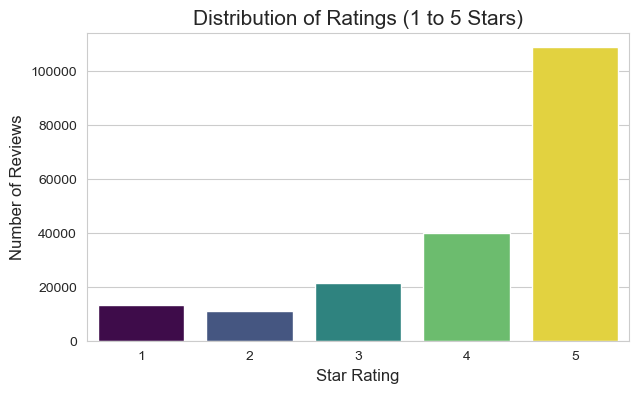

In [8]:
# --- Step 2: Visualizing Rating Distribution --- 

# Creating the bar chart
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='overall', hue='overall', palette='viridis', legend=False)

# Adding labels
plt.title('Distribution of Ratings (1 to 5 Stars)', fontsize=15)
plt.xlabel('Star Rating', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12);

plt.show()

# 4. Data Cleaning & Text Normalization
**Description**: In this section, we perform a complete cleanup of the dataset. First, we ensure data integrity by removing null values and duplicates. Then, we normalize the text by converting it to lowercase and removing special characters. This process is essential to reduce noise and ensure the model focuses on the actual sentiment of the reviews.

### 4.1. Handling Nulls and Duplicates

To ensure the reliability of our analysis, we start by auditing the dataset structure. We will identify and remove any missing values (NaNs) or duplicate reviews that could lead to redundant information and biased model results.

In [9]:
# --- Step 1: Removing Missing Values ---

# Storing initial size for comparison
initial_size = len(df)

# Dropping rows where the review text is missing
df.dropna(subset=['reviewText'], inplace=True)

print(f"Step 1 Complete: Missing values checked.")

# --- Step 2: Removing Duplicates ---

# Considering duplicate if the text and the reviewer ID are the same
df.drop_duplicates(subset=['reviewText', 'reviewerID'], inplace=True)

# Calculating the impact of cleaning
final_size = len(df)
print(f"Rows removed: {initial_size - final_size}")
print(f"Final dataset size: {final_size}")

Step 1 Complete: Missing values checked.
Rows removed: 0
Final dataset size: 194439


**Description**: Ensuring data integrity by removing incomplete records and redundant entries to prevent model bias. 

### 4.2. Text Standardization 

Natural Language Processing requires uniform data. In this step, we apply a normalization function to convert all text to lowercase and remove accents, punctuation, and special characters. This process focuses the model on the actual vocabulary rather than formatting inconsistencies.

In [10]:
# --- Step 3: Defining the Text Normalization Function ---

def clean_text(text):
    # Ensures the input is a string to avoid errors
    if not isinstance(text, str):
        return ""

    # Normalization (Handling accents and foreign characters)
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')

    # Lowercase & Noise Removal (Keeping only letters and spaces)
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text) 
    
    # Trim spaces
    text = text.strip()
    
    return text

# --- Step 4: Applying Normalization to the Dataset ---

# Applying the optimized cleaning function to create a new feature
df['cleaned_review'] = df['reviewText'].apply(clean_text)

# Checking the result (Before vs. After)
df[['reviewText', 'cleaned_review']].head()

,reviewText,cleaned_review
0,They look good and stick good! I just don't li...,they look good and stick good i just dont like...
1,These stickers work like the review says they ...,these stickers work like the review says they ...
2,These are awesome and make my phone look so st...,these are awesome and make my phone look so st...
3,Item arrived in great time and was in perfect ...,item arrived in great time and was in perfect ...
4,"awesome! stays on, and looks great. can be use...",awesome stays on and looks great can be used o...


**Description**: After applying the cleaning function, the text is now standardized. By removing accents, special characters, and converting all reviews to lowercase, we have eliminated linguistic noise. This ensures that the model recognizes words based on their semantic value rather than their formatting or punctuation, which is a critical step for high-quality Natural Language Processing.

### 4.3. Statistical Text Analysis: Top 20 Words

To validate the effectiveness of our cleaning process, we will now analyze the most frequent words in the dataset. This step helps us identify the core themes and ensure that common "stop words" have been successfully filtered out.

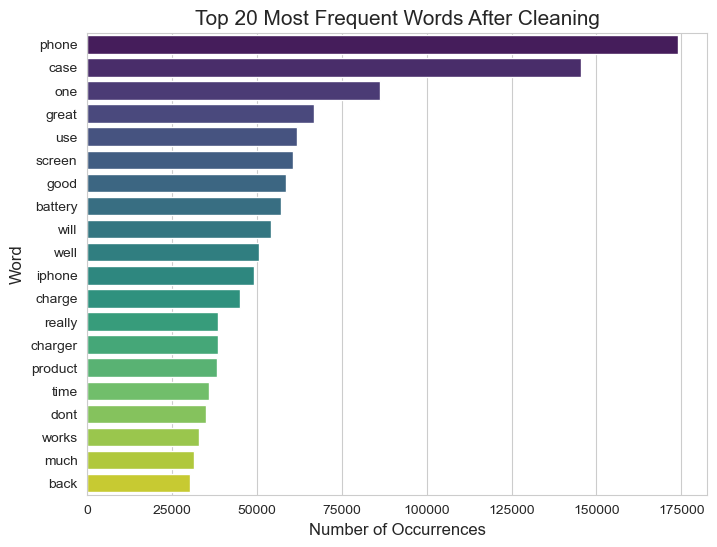

In [11]:
# --- Step 1: Defining the Stop Words set ---

# Using the predefined STOPWORDS list to ensure the analysis focuses on content
stop_words_list = set(STOPWORDS)

# --- Step 2: Processing Text and Counting Frequencies ---

# Combining all reviews and splitting into individual words
all_words = " ".join(df['cleaned_review']).split()

# Filtering: keeping only words NOT in the stop_words_list
meaningful_words = [word for word in all_words if word not in stop_words_list]

# Counting occurrences
word_counts = Counter(meaningful_words)
top_20_words = word_counts.most_common(20)

# Converting to a DataFrame for easier visualization
df_top_20 = pd.DataFrame(top_20_words, columns=['Word', 'Count'])

# --- Step 3: Visualizing Word Frequency ---

plt.figure(figsize=(8, 6))
sns.barplot(
    data=df_top_20, 
    x='Count', 
    y='Word', 
    hue='Word', 
    palette='viridis', 
    legend=False
)

plt.title('Top 20 Most Frequent Words After Cleaning', fontsize=15)
plt.xlabel('Number of Occurrences', fontsize=12)
plt.ylabel('Word', fontsize=12)
plt.show()

**Description**: The chart confirms that the dataset is clean and relevant. The most frequent terms (such as "phone", "case", and "great") are meaningful for our sentiment analysis, and the absence of grammatical noise proves that our preprocessing was successful.

# 5. Sentiment Labeling (Target Definition)

To prepare the dataset for machine learning, I converted the star ratings into binary categories: **Positive (1)** and **Negative (0)**. I made the strategic decision to remove 3-star reviews (neutral) because they often contain ambiguous vocabulary that can confuse the model. By focusing on polarized ratings (1-2 and 4-5), I ensure the model learns from clear and distinct emotional signals.

In [12]:
# --- Step 1: Filtering Neutral Reviews ---
# Removing 3-star reviews to eliminate linguistic noise and focus on polarized signals
df_model = df[df['overall'] != 3].copy()

# --- Step 2: Mapping Ratings to Binary Labels ---
# Assigning 1 (Positive) for ratings 4-5, and 0 (Negative) for ratings
df_model['sentimento_label'] = df_model['overall'].apply(lambda x: 1 if x >= 4 else 0)

# --- Step 3: Verifying the New Distribution ---
print(f"Dataset size after filtering: {len(df_model)}")
print("\nSentiment Distribution (Percentage):")
print(df_model['sentimento_label'].value_counts(normalize=True) * 100)

# --- Step 4: Visualizing the Processed Data ---
# Displaying a random sample to confirm the labeling logic
print("\nDataFrame after labeling (Random Sample):")
df_model[['cleaned_review', 'overall', 'sentimento_label']].sample(6)

Dataset size after filtering: 173000

Sentiment Distribution (Percentage):
sentimento_label
1    85.928902
0    14.071098
Name: proportion, dtype: float64

DataFrame after labeling (Random Sample):


,cleaned_review,overall,sentimento_label
128167,i have boughten of these covers as i cant bel...,5,1
14487,used this for the first time today to charge m...,5,1
57880,i received it with in the specified time frame...,2,0
133341,these are cute but not well painted the paint ...,2,0
155671,right up front ill tell you that i love spigen...,1,0
32581,great battery works well with my lg cellphone...,5,1


**Description**: I noticed a significant class imbalance, with 86% of reviews being positive. To ensure the model doesn't become biased toward the majority class, I will prioritize evaluation metrics like **Precision, Recall, and F1-Score** instead of just Accuracy.

# Section 6: Text Vectorization (TF-IDF)

Since machine learning models can only process numerical data, I will convert the cleaned text into a numerical matrix using the TF-IDF Vectorizer. This technique is superior to simple word counting because it penalizes common words and highlights terms that carry more significant semantic meaning for sentiment classification.

In [13]:
# --- Step 1: Initializing the Vectorizer ---
# Limiting the features to the 5,000 most important words to optimize model performance
tfidf = TfidfVectorizer(max_features=5000)

# --- Step 2: Transforming the Text ---
# X will be our features (the reviews) and y will be our target (the sentiment)
X = tfidf.fit_transform(df_model['cleaned_review'])
y = df_model['sentimento_label']

# --- Step 3: Checking the Matrix Shape ---
print(f"Feature Matrix Shape: {X.shape}")
print(f"Target Array Shape: {y.shape}")

Feature Matrix Shape: (173000, 5000)
Target Array Shape: (173000,)


**Description**: The resulting feature matrix has 5,000 columns, each representing a unique word weighted by its importance across the dataset. This high-dimensional representation allows the machine learning model to identify complex patterns between specific vocabulary and the sentiment labels (0 and 1) defined in the previous step.

# Section 7: Train-Test Split

I will split the dataset into **75% for training** and **25% for testing**. To handle the class imbalance (86% vs 14%) identified earlier, I am using the *stratify* parameter, which ensures that both sets maintain the same proportion of positive and negative reviews. For the classification task, I chose **Logistic Regression**, a robust and efficient algorithm for high-dimensional text data.

In [14]:
# --- Step 1: Splitting the Data (75% Train, 25% Test) ---
# Stratify=y ensures the 86/14 balance is preserved in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# --- Step 2: Training the Initial Model (Baseline) ---
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# --- Step 3: Making Predictions and Initial Evaluation ---
y_pred = model.predict(X_test)

print("Model Performance Report:\n")
print(classification_report(y_test, y_pred))

Model Performance Report:

              precision    recall  f1-score   support

           0       0.83      0.61      0.71      6086
           1       0.94      0.98      0.96     37164

    accuracy                           0.93     43250
   macro avg       0.89      0.80      0.83     43250
weighted avg       0.92      0.93      0.92     43250



The initial model showed high accuracy but struggled with the minority class, capturing **only 61% of negative reviews** (Recall). In a business context like payment disputes or customer experience, leaving 39% of complaints undetected is a **significant risk**. This 'conservative' behavior happened because the model was biased toward the majority class (Positive reviews).

In [15]:
# --- Step 4: Training Version 2.0 (Balanced Weights) ---
# Applying class_weight='balanced' to penalize errors in the minority class (Negative)
model_v2 = LogisticRegression(max_iter=1000, class_weight='balanced')
model_v2.fit(X_train, y_train)

# --- Step 5: Evaluating Version 2.0 ---
y_pred_v2 = model_v2.predict(X_test)

print("Model Performance Report (Version 2.0 - Balanced):\n")
print(classification_report(y_test, y_pred_v2))

Model Performance Report (Version 2.0 - Balanced):

              precision    recall  f1-score   support

           0       0.57      0.88      0.69      6086
           1       0.98      0.89      0.93     37164

    accuracy                           0.89     43250
   macro avg       0.77      0.88      0.81     43250
weighted avg       0.92      0.89      0.90     43250



By applying *class_weight='balanced'*, I significantly improved the model's sensitivity. The Recall for negative reviews jumped to **88%**, ensuring that the vast majority of **dissatisfied customers are identified**. Although this led to more 'false alarms' (lower precision), in a 'People First' management approach, it is often better to over-identify potential issues for human review than to miss a customer in distress.

# Section 8: Predictive Modeling Pipeline and Model Optimization (Hyperparameter Tuning)

To streamline the process and ensure consistency between training and production environments, I will consolidate the vectorization and the balanced Logistic Regression model into a single **Scikit-Learn Pipeline**. This structure simplifies the deployment process, allowing raw text to be fed directly into the model for sentiment prediction.

In [16]:
# --- Step 1: Defining the Pipeline ---
# This "bundle" includes the TF-IDF Vectorizer and the Balanced Model
pipeline = Pipeline([
    # Step 1: Converting text to numbers using TF-
    # ngram_range=(1, 2) allows the model to capture phrases like "not good" or "very happy"
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),

    # Step 2: The Machine Learning model (Logistic Regression)
    # I am using 'class_weight=balanced' to ensure the model pays extra attention to negative reviews.
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# --- Step 2: Training the entire Pipeline ---
# The pipeline automatically applies TF-IDF and then trains the model in one flow
pipeline.fit(df_model['cleaned_review'], df_model['sentimento_label'])

print("Pipeline successfully trained and ready for production!")

Pipeline successfully trained and ready for production!


After establishing the Pipeline structure, I am now applying **GridSearchCV** to fine-tune the model's performance. By testing different values for the regularization parameter *(C)* and the vocabulary size *(max_features)*, I aim to find the most efficient configuration. This optimization is key to balancing the model's precision and recall, ensuring it can accurately distinguish between positive and negative feedback in a real-world scenario

In [17]:
# --- Step 3: Hyperparameter Tuning with GridSearchCV ---

# Defining a targeted grid to optimize the model efficiently
param_grid_fast = {
    'tfidf__max_features': [5000],  # Keeping the best performing vocabulary size
    'classifier__C': [0.1, 1, 10]    # Testing different strengths of regularization
}

# Setting up the Search
# Using 'f1_macro' to ensure the optimization balances both 
# sentiment classes equally
grid_search = GridSearchCV(
    pipeline, 
    param_grid_fast, 
    cv=2, 
    scoring='f1_macro', 
    n_jobs=-1, 
    verbose=1
)

# Running the optimization
# This will find the best combination of the parameters defined above.
grid_search.fit(df_model['cleaned_review'], df_model['sentimento_label'])

Fitting 2 folds for each of 3 candidates, totalling 6 fits


GridSearchCV(cv=2,
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(max_features=5000,
                                                        ngram_range=(1, 2))),
                                       ('classifier',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=1000))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.1, 1, 10],
                         'tfidf__max_features': [5000]},
             scoring='f1_macro', verbose=1)

In [18]:
print("\nBest hyperparameters found:\n")
print(grid_search.best_params_)


Best hyperparameters found:

{'classifier__C': 10, 'tfidf__max_features': 5000}


# Section 9: Model Evaluation and Metrics Interpretation

In this final stage, I evaluate the optimized model's performance. My analysis focuses on how the model handles the trade-off between precision and recall, especially for the negative class.


Model Accuracy: 91.37%

-----------------------------------------------------

Classification Report:

              precision    recall  f1-score   support

    Negative       0.63      0.93      0.75      6086
    Positive       0.99      0.91      0.95     37164

    accuracy                           0.91     43250
   macro avg       0.81      0.92      0.85     43250
weighted avg       0.94      0.91      0.92     43250



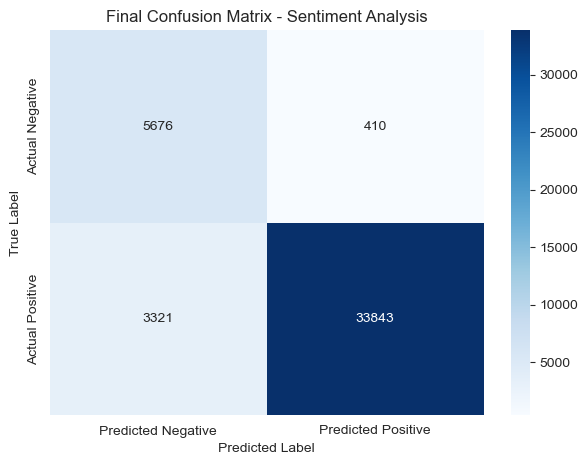


Final model saved successfully as 'final_sentiment_model.pkl'!


In [19]:
# --- Step 1: Final Prediction ---
# I retrieve the original text (strings) using the index from our train_test_split.
# This ensures I pass RAW TEXT to the pipeline, allowing it to handle the TF-IDF 
# transformation internally as design
text_test = df_model['cleaned_review'].loc[y_test.index]

y_pred = grid_search.best_estimator_.predict(text_test)

# --- Step 2: Accuracy and Classification Report ---
# Generating the official performance metrics
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=['Negative', 'Positive'])

print(f"\nModel Accuracy: {accuracy:.2%}\n")
print("-" * 53)
print("\nClassification Report:\n")
print(report)

# --- Step 3: Confusion Matrix Visualization ---
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Final Confusion Matrix - Sentiment Analysis')
plt.show()

# --- Step 4: Exporting the Final Model ---
# Serializing the best model into a .pkl file for future deployment
joblib.dump(grid_search.best_estimator_, 'final_sentiment_model.pkl')
print("\nFinal model saved successfully as 'final_sentiment_model.pkl'!")

### 1. Accuracy: 91.37%

**Definition**: The overall percentage of correct predictions across the entire test set.

**Analysis**:Out of **43,250 total reviews**, the model **correctly classified over 39,500 cases**. While 91% is a strong general performance, accuracy can be misleading in imbalanced datasets (86% Positive vs. 14% Negative). Therefore, I **prioritized class-specific metrics** to ensure the model is not simply biased toward the majority.

### 2. Precision (Negative Class): 0.63

**Definition**: Out of all reviews the model predicted as "Negative", how many were actually negative?

**Analysis**: The model flagged 8,997 reviews as negative. Among these, **5,676 were correct (True Negatives)**, while 3,321 were actually positive (False Positives).

**Strategic Impact**: A precision of 63% implies a moderate rate of "false alarms." In a customer experience pipeline, this means some positive feedback will be flagged for manual review, which is a calculated trade-off **to ensure no critical complaints are missed**.

### 3. Recall (Negative Class): 0.93

**Definition**: Out of all actual negative reviews in the dataset, how many did the model successfully find?

**Analysis**: This is the most successful metric of the project. There were 6,086 actual negative reviews, and **the model captured 5,676 of them**.

**Strategic Impact**: A **93% Recall** is vital for crisis detection. It ensures that the vast majority of dissatisfied customers are identified, leaving only 410 undetected cases, **less than 1% of the total test volume**. This level of sensitivity is ideal for proactive sentiment monitoring.

### 4. F1-Score (Negative Class): 0.75

**Definition**: The harmonic mean between Precision and Recall, providing a balanced "grade" for the class.

**Analysis**: Achieving a **0.75 F1-Score** on the minority class (which represents only 14% of the data) proves that the model is robust. The use of *class_weight='balanced'* and hyperparameter optimization successfully prevented the model from ignoring the negative sentiment.

### 5. Support: 43,250 Samples

**Definition**: The number of actual occurrences of each class in the test set.

**Analysis**: The test set contained **37,164 Positive** and **6,086 Negative reviews**.

**Conclusion**: This high volume of support validates the statistical significance of the results. The model has been tested against a large-scale dataset, ensuring that the performance metrics are representative of real-world text variety.

## Section 10: Model Deployment & Interactive Testing (Sanity Check)

In this final stage, I transition from model evaluation to a practical demonstration. By loading the serialized 'Champion' model (the .pkl file), I can simulate a real-world production environment. The following interactive tool allows for manual input to verify the model's behavior on new, unseen sentences, ensuring that the entire pipeline—from text preprocessing to sentiment classification—is functioning as expected.

In [20]:
# Load the production-ready model
try:
    loaded_model = joblib.load('final_sentiment_model.pkl')
    print("Success: Production model loaded correctly.\n")
except FileNotFoundError:
    print("Error: The model file was not found. Please ensure the 'dump' step was completed.\n")

def live_test():
    print("--- Sentiment Analysis Tool ---")
    print("Enter a review below to test the model (or type 'exit' to stop):")
    
    while True:
        user_input = input("\nYour Review: ")
        
        if user_input.lower() == 'exit':
            print("Exiting the predictor. Great job!")
            break
        
        # Predicting the sentiment
        # The pipeline handles the TF-IDF transformation automatically
        prediction = loaded_model.predict([user_input])[0]
        sentiment = "POSITIVE" if prediction == 1 else "NEGATIVE"
        
        # Displaying the result
        print(f"Model Analysis: This review is {sentiment}")

# Run the interactive session
live_test()

Success: Production model loaded correctly.

--- Sentiment Analysis Tool ---
Enter a review below to test the model (or type 'exit' to stop):



Your Review:  I liked it, its really nice


Model Analysis: This review is POSITIVE



Your Review:  ITS OKAY, NOT MY FAVOURITE!!!


Model Analysis: This review is NEGATIVE



Your Review:  exit


Exiting the predictor. Great job!
